In [115]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

Data Preparation

In [116]:
data=pd.read_csv("car_price_prediction.csv")

In [117]:
data.describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,2010.912824,4.582991,6.582627
std,9.365914e+05,1.905813e+05,5.668673,1.199933,4.320168
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


In [118]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

In [119]:
data.shape

(19237, 18)

In [120]:
data.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


Data Preprocessing

In [121]:
data["ID"].is_unique

False

In [122]:
print(data["ID"].duplicated().sum())

313


In [123]:
data.duplicated().sum()

np.int64(313)

In [124]:
data.drop_duplicates(inplace=True)

In [125]:
data.duplicated().sum()

np.int64(0)

In [126]:
data.drop(columns="ID",inplace=True)

In [127]:
data.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [128]:
data["Levy"][data["Levy"]=='-'].count()
# data.loc[("Levy" == "-"), "Levy"].count()
data["Levy"]=data["Levy"].replace(to_replace='-',value=np.nan)

In [129]:
data["Levy"][data["Levy"]=='-'].count()

np.int64(0)

In [130]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             18924 non-null  int64  
 1   Levy              13215 non-null  object 
 2   Manufacturer      18924 non-null  object 
 3   Model             18924 non-null  object 
 4   Prod. year        18924 non-null  int64  
 5   Category          18924 non-null  object 
 6   Leather interior  18924 non-null  object 
 7   Fuel type         18924 non-null  object 
 8   Engine volume     18924 non-null  object 
 9   Mileage           18924 non-null  object 
 10  Cylinders         18924 non-null  float64
 11  Gear box type     18924 non-null  object 
 12  Drive wheels      18924 non-null  object 
 13  Doors             18924 non-null  object 
 14  Wheel             18924 non-null  object 
 15  Color             18924 non-null  object 
 16  Airbags           18924 non-null  int64  
dty

In [131]:
data["Levy"].isna().sum()

np.int64(5709)

In [132]:
data["Levy"]=data["Levy"].astype(dtype="float64")

In [133]:
data["Levy"].describe()

count    13215.000000
mean       906.299205
std        463.296871
min         87.000000
25%        640.000000
50%        781.000000
75%       1058.000000
max      11714.000000
Name: Levy, dtype: float64

In [134]:
data.groupby(["Price"])["Levy"].mean()

Price
1           1202.000000
3            727.714286
6            425.666667
9                   NaN
19                  NaN
               ...     
297930              NaN
308906      1694.000000
627220              NaN
872946      2067.000000
26307500            NaN
Name: Levy, Length: 2315, dtype: float64

<Axes: >

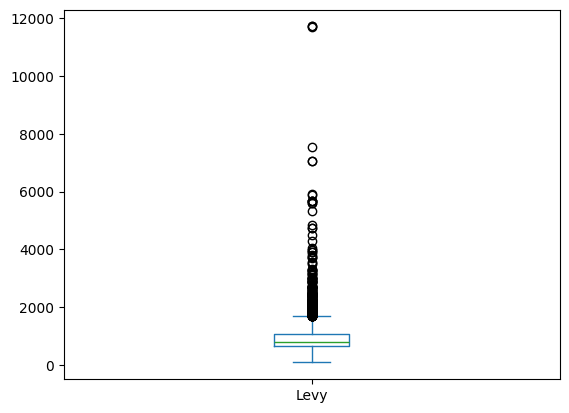

In [135]:
data["Levy"].plot(kind="box")

<Axes: >

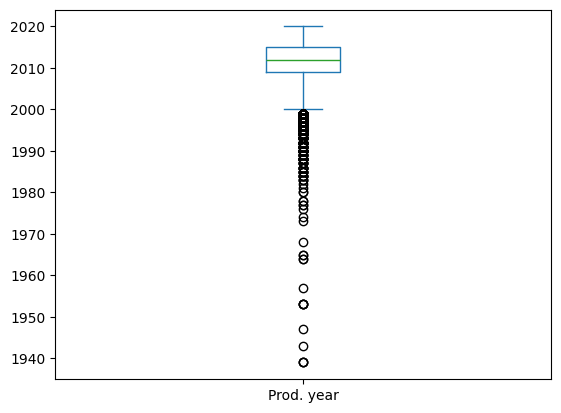

In [136]:
data["Prod. year"].plot(kind="box")

<Axes: >

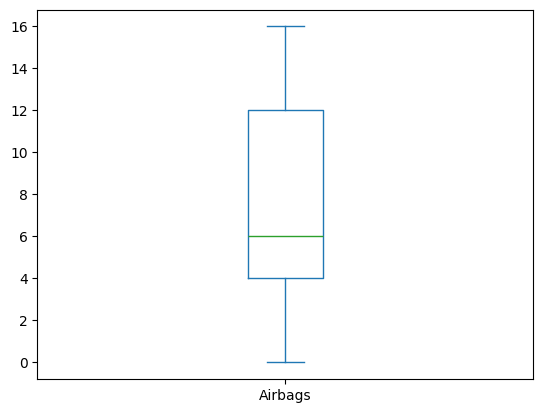

In [137]:
data["Airbags"].plot(kind="box")

In [138]:
q1=data['Levy'].quantile(0.25)
q3=data['Levy'].quantile(0.75)
iqr=q3-q1
upper=q3+(1.5*iqr)
lower=q1-(1.5*iqr)
x=data['Levy'][(data['Levy']>upper) | (data['Levy']<lower)]
y = x.nlargest(20)
d = data.loc[y.index]
print(d)
#OUTliers here are logical

       Price     Levy   Manufacturer                 Model  Prod. year  \
115    11917  11714.0  MERCEDES-BENZ             E 500 AMG        2003   
18984  11917  11714.0  MERCEDES-BENZ                 E 500        2003   
18957  14740  11706.0  MERCEDES-BENZ             E 500 AVG        2005   
17117   7213   7536.0     MITSUBISHI                Pajero        2000   
3994   13172   7063.0         TOYOTA               Alphard        2003   
2159   10349   7058.0         SUBARU                Legacy        2005   
5529    5645   5908.0            BMW                   520        1999   
5367    7840   5877.0  MERCEDES-BENZ               CLK 430        2005   
17767  10349   5681.0     MITSUBISHI                Pajero        1996   
2323    3150   5679.0         TOYOTA                Estima        1997   
14676   7840   5679.0  MERCEDES-BENZ                 C 240        1997   
8160   12544   5666.0         TOYOTA                 Ipsum        2004   
2357   10036   5603.0        HYUNDAI  

In [139]:
data.groupby("Fuel type")["Levy"].median()

Fuel type
CNG               1527.0
Diesel             891.0
Hybrid             640.0
Hydrogen             NaN
LPG                765.0
Petrol             831.0
Plug-in Hybrid     474.0
Name: Levy, dtype: float64

In [140]:
#suppose that levy depends on fuel type
data["Levy"] = data["Levy"].fillna(data.groupby("Fuel type")["Levy"].transform("mean"))

In [141]:
data["Levy"].isnull().sum()

np.int64(1)

In [142]:
data["Levy"] = data["Levy"].fillna(data["Levy"].median())

In [143]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             18924 non-null  int64  
 1   Levy              18924 non-null  float64
 2   Manufacturer      18924 non-null  object 
 3   Model             18924 non-null  object 
 4   Prod. year        18924 non-null  int64  
 5   Category          18924 non-null  object 
 6   Leather interior  18924 non-null  object 
 7   Fuel type         18924 non-null  object 
 8   Engine volume     18924 non-null  object 
 9   Mileage           18924 non-null  object 
 10  Cylinders         18924 non-null  float64
 11  Gear box type     18924 non-null  object 
 12  Drive wheels      18924 non-null  object 
 13  Doors             18924 non-null  object 
 14  Wheel             18924 non-null  object 
 15  Color             18924 non-null  object 
 16  Airbags           18924 non-null  int64  
dty

In [144]:
data["Engine volume"].unique()

array(['3.5', '3', '1.3', '2.5', '2', '1.8', '2.4', '4', '1.6', '3.3',
       '2.0 Turbo', '2.2 Turbo', '4.7', '1.5', '4.4', '3.0 Turbo',
       '1.4 Turbo', '3.6', '2.3', '1.5 Turbo', '1.6 Turbo', '2.2',
       '2.3 Turbo', '1.4', '5.5', '2.8 Turbo', '3.2', '3.8', '4.6', '1.2',
       '5', '1.7', '2.9', '0.5', '1.8 Turbo', '2.4 Turbo', '3.5 Turbo',
       '1.9', '2.7', '4.8', '5.3', '0.4', '2.8', '3.2 Turbo', '1.1',
       '2.1', '0.7', '5.4', '1.3 Turbo', '3.7', '1', '2.5 Turbo', '2.6',
       '1.9 Turbo', '4.4 Turbo', '4.7 Turbo', '0.8', '0.2 Turbo', '5.7',
       '4.8 Turbo', '4.6 Turbo', '6.7', '6.2', '1.2 Turbo', '3.4',
       '1.7 Turbo', '6.3 Turbo', '2.7 Turbo', '4.3', '4.2', '2.9 Turbo',
       '0', '4.0 Turbo', '20', '3.6 Turbo', '0.3', '3.7 Turbo', '5.9',
       '5.5 Turbo', '0.2', '2.1 Turbo', '5.6', '6', '0.7 Turbo',
       '0.6 Turbo', '6.8', '4.5', '0.6', '7.3', '0.1', '1.0 Turbo', '6.3',
       '4.5 Turbo', '0.8 Turbo', '4.2 Turbo', '3.1', '5.0 Turbo', '6.4',
       '3

In [145]:
data["Engine volume"] = data["Engine volume"].str.replace(" Turbo", "", regex=False)

In [146]:
data['Engine volume']=data["Engine volume"].astype("float64")

In [147]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             18924 non-null  int64  
 1   Levy              18924 non-null  float64
 2   Manufacturer      18924 non-null  object 
 3   Model             18924 non-null  object 
 4   Prod. year        18924 non-null  int64  
 5   Category          18924 non-null  object 
 6   Leather interior  18924 non-null  object 
 7   Fuel type         18924 non-null  object 
 8   Engine volume     18924 non-null  float64
 9   Mileage           18924 non-null  object 
 10  Cylinders         18924 non-null  float64
 11  Gear box type     18924 non-null  object 
 12  Drive wheels      18924 non-null  object 
 13  Doors             18924 non-null  object 
 14  Wheel             18924 non-null  object 
 15  Color             18924 non-null  object 
 16  Airbags           18924 non-null  int64  
dty

In [148]:
data["Mileage"].unique()

array(['186005 km', '192000 km', '200000 km', ..., '140607 km',
       '307325 km', '186923 km'], shape=(7687,), dtype=object)

In [149]:
data["Mileage"] = data["Mileage"].str.replace(" km", "", regex=False)
data["Mileage"]=data["Mileage"].astype("float64")

<Axes: >

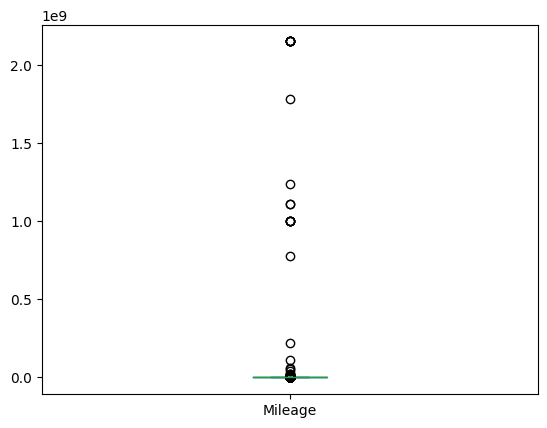

In [150]:
data["Mileage"].plot(kind="box")

In [151]:
q1=data['Mileage'].quantile(0.25)
q3=data['Mileage'].quantile(0.75)
iqr=q3-q1
upper=q3+(1.5*iqr)
lower=q1-(1.5*iqr)
x=data['Mileage'][(data['Mileage']>upper) | (data['Mileage']<lower)]
data["Mileage"][data["Mileage"] > 1000000].count()


np.int64(73)

In [152]:
data.loc[data["Mileage"] > 1000000, "Mileage"] = q3

In [153]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             18924 non-null  int64  
 1   Levy              18924 non-null  float64
 2   Manufacturer      18924 non-null  object 
 3   Model             18924 non-null  object 
 4   Prod. year        18924 non-null  int64  
 5   Category          18924 non-null  object 
 6   Leather interior  18924 non-null  object 
 7   Fuel type         18924 non-null  object 
 8   Engine volume     18924 non-null  float64
 9   Mileage           18924 non-null  float64
 10  Cylinders         18924 non-null  float64
 11  Gear box type     18924 non-null  object 
 12  Drive wheels      18924 non-null  object 
 13  Doors             18924 non-null  object 
 14  Wheel             18924 non-null  object 
 15  Color             18924 non-null  object 
 16  Airbags           18924 non-null  int64  
dty

Category encoding

In [154]:
data["Manufacturer"].unique()

array(['LEXUS', 'CHEVROLET', 'HONDA', 'FORD', 'HYUNDAI', 'TOYOTA',
       'MERCEDES-BENZ', 'OPEL', 'PORSCHE', 'BMW', 'JEEP', 'VOLKSWAGEN',
       'AUDI', 'RENAULT', 'NISSAN', 'SUBARU', 'DAEWOO', 'KIA',
       'MITSUBISHI', 'SSANGYONG', 'MAZDA', 'GMC', 'FIAT', 'INFINITI',
       'ALFA ROMEO', 'SUZUKI', 'ACURA', 'LINCOLN', 'VAZ', 'GAZ',
       'CITROEN', 'LAND ROVER', 'MINI', 'DODGE', 'CHRYSLER', 'JAGUAR',
       'ISUZU', 'SKODA', 'DAIHATSU', 'BUICK', 'TESLA', 'CADILLAC',
       'PEUGEOT', 'BENTLEY', 'VOLVO', 'სხვა', 'HAVAL', 'HUMMER', 'SCION',
       'UAZ', 'MERCURY', 'ZAZ', 'ROVER', 'SEAT', 'LANCIA', 'MOSKVICH',
       'MASERATI', 'FERRARI', 'SAAB', 'LAMBORGHINI', 'ROLLS-ROYCE',
       'PONTIAC', 'SATURN', 'ASTON MARTIN', 'GREATWALL'], dtype=object)

In [155]:
data['Car']=data['Manufacturer']+'_'+data['Model']

In [156]:
data['Car'].nunique()

1601

In [157]:
from category_encoders import TargetEncoder
encoder = TargetEncoder(cols=["Car"])
data["Car"] = encoder.fit_transform(data["Car"], data["Price"])

In [158]:
data['Car'].head()

0    10658.571753
1    13047.967634
2    11102.885135
3     8172.583064
4    11102.885135
Name: Car, dtype: float64

label encoding

In [159]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [160]:
data=data.drop(columns=['Manufacturer','Model'],axis=1)

In [161]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             18924 non-null  int64  
 1   Levy              18924 non-null  float64
 2   Prod. year        18924 non-null  int64  
 3   Category          18924 non-null  object 
 4   Leather interior  18924 non-null  object 
 5   Fuel type         18924 non-null  object 
 6   Engine volume     18924 non-null  float64
 7   Mileage           18924 non-null  float64
 8   Cylinders         18924 non-null  float64
 9   Gear box type     18924 non-null  object 
 10  Drive wheels      18924 non-null  object 
 11  Doors             18924 non-null  object 
 12  Wheel             18924 non-null  object 
 13  Color             18924 non-null  object 
 14  Airbags           18924 non-null  int64  
 15  Car               18924 non-null  float64
dtypes: float64(5), int64(3), object(8)
memory usa

In [162]:
data['Leather interior'].unique()

array(['Yes', 'No'], dtype=object)

In [163]:
data['Leather interior']=le.fit_transform(data['Leather interior'])

In [164]:
data.head()

,Price,Levy,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Car
0,13328,1399.000000,2010,Jeep,1,Hybrid,3.5,186005.0,6.0,Automatic,4x4,04-May,Left wheel,Silver,12,10658.571753
1,16621,1018.000000,2011,Jeep,0,Petrol,3.0,192000.0,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8,13047.967634
2,8467,968.782372,2006,Hatchback,0,Petrol,1.3,200000.0,4.0,Variator,Front,04-May,Right-hand drive,Black,2,11102.885135
3,3607,862.000000,2011,Jeep,1,Hybrid,2.5,168966.0,4.0,Automatic,4x4,04-May,Left wheel,White,0,8172.583064
4,11726,446.000000,2014,Hatchback,1,Petrol,1.3,91901.0,4.0,Automatic,Front,04-May,Left wheel,Silver,4,11102.885135


In [165]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             18924 non-null  int64  
 1   Levy              18924 non-null  float64
 2   Prod. year        18924 non-null  int64  
 3   Category          18924 non-null  object 
 4   Leather interior  18924 non-null  int64  
 5   Fuel type         18924 non-null  object 
 6   Engine volume     18924 non-null  float64
 7   Mileage           18924 non-null  float64
 8   Cylinders         18924 non-null  float64
 9   Gear box type     18924 non-null  object 
 10  Drive wheels      18924 non-null  object 
 11  Doors             18924 non-null  object 
 12  Wheel             18924 non-null  object 
 13  Color             18924 non-null  object 
 14  Airbags           18924 non-null  int64  
 15  Car               18924 non-null  float64
dtypes: float64(5), int64(4), object(7)
memory usa

In [166]:
data["Doors"] = data["Doors"].replace(to_replace="04-May", value="4-5")
data["Doors"] = data["Doors"].replace(to_replace="02-Mar", value="2-3")

In [167]:
data['Doors']=le.fit_transform(data['Doors'])

In [168]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             18924 non-null  int64  
 1   Levy              18924 non-null  float64
 2   Prod. year        18924 non-null  int64  
 3   Category          18924 non-null  object 
 4   Leather interior  18924 non-null  int64  
 5   Fuel type         18924 non-null  object 
 6   Engine volume     18924 non-null  float64
 7   Mileage           18924 non-null  float64
 8   Cylinders         18924 non-null  float64
 9   Gear box type     18924 non-null  object 
 10  Drive wheels      18924 non-null  object 
 11  Doors             18924 non-null  int64  
 12  Wheel             18924 non-null  object 
 13  Color             18924 non-null  object 
 14  Airbags           18924 non-null  int64  
 15  Car               18924 non-null  float64
dtypes: float64(5), int64(5), object(6)
memory usa

In [169]:
data["Wheel"].unique()

array(['Left wheel', 'Right-hand drive'], dtype=object)

In [170]:
data['Wheel']=le.fit_transform(data['Wheel'])

One-Hot encoding

In [171]:
data['Fuel type'].unique()

array(['Hybrid', 'Petrol', 'Diesel', 'CNG', 'Plug-in Hybrid', 'LPG',
       'Hydrogen'], dtype=object)

In [172]:
data['Category'].unique()

array(['Jeep', 'Hatchback', 'Sedan', 'Microbus', 'Goods wagon',
       'Universal', 'Coupe', 'Minivan', 'Cabriolet', 'Limousine',
       'Pickup'], dtype=object)

In [173]:
data["Gear box type"].unique()

array(['Automatic', 'Tiptronic', 'Variator', 'Manual'], dtype=object)

In [174]:
data["Drive wheels"].unique()

array(['4x4', 'Front', 'Rear'], dtype=object)

In [175]:
data["Doors"].unique()

array([1, 0, 2])

In [176]:
data["Color"].unique()

array(['Silver', 'Black', 'White', 'Grey', 'Blue', 'Green', 'Red',
       'Sky blue', 'Orange', 'Yellow', 'Brown', 'Golden', 'Beige',
       'Carnelian red', 'Purple', 'Pink'], dtype=object)

In [177]:
data = pd.get_dummies(data,columns=["Category"])
data = pd.get_dummies(data,columns=["Fuel type"])
data = pd.get_dummies(data,columns=["Gear box type"])
data = pd.get_dummies(data,columns=["Drive wheels"])
data = pd.get_dummies(data,columns=["Color"])

In [178]:
data.head()

,Price,Levy,Prod. year,Leather interior,Engine volume,Mileage,Cylinders,Doors,Wheel,Airbags,...,Color_Green,Color_Grey,Color_Orange,Color_Pink,Color_Purple,Color_Red,Color_Silver,Color_Sky blue,Color_White,Color_Yellow
0,13328,1399.000000,2010,1,3.5,186005.0,6.0,1,0,12,...,False,False,False,False,False,False,True,False,False,False
1,16621,1018.000000,2011,0,3.0,192000.0,6.0,1,0,8,...,False,False,False,False,False,False,False,False,False,False
2,8467,968.782372,2006,0,1.3,200000.0,4.0,1,1,2,...,False,False,False,False,False,False,False,False,False,False
3,3607,862.000000,2011,1,2.5,168966.0,4.0,1,0,0,...,False,False,False,False,False,False,False,False,True,False
4,11726,446.000000,2014,1,1.3,91901.0,4.0,1,0,4,...,False,False,False,False,False,False,True,False,False,False


In [179]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 52 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Price                     18924 non-null  int64  
 1   Levy                      18924 non-null  float64
 2   Prod. year                18924 non-null  int64  
 3   Leather interior          18924 non-null  int64  
 4   Engine volume             18924 non-null  float64
 5   Mileage                   18924 non-null  float64
 6   Cylinders                 18924 non-null  float64
 7   Doors                     18924 non-null  int64  
 8   Wheel                     18924 non-null  int64  
 9   Airbags                   18924 non-null  int64  
 10  Car                       18924 non-null  float64
 11  Category_Cabriolet        18924 non-null  bool   
 12  Category_Coupe            18924 non-null  bool   
 13  Category_Goods wagon      18924 non-null  bool   
 14  Category_Ha

Handling outliers of the target

<Axes: >

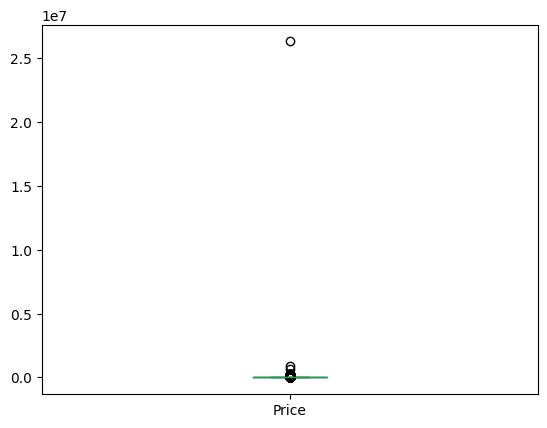

In [180]:
data["Price"].plot(kind="box")

In [181]:
q1=data['Price'].quantile(0.25)
q3=data['Price'].quantile(0.75)
iqr=q3-q1
upper=q3+(1.5*iqr)
lower=q1-(1.5*iqr)
x=data['Price'][(data['Price']>upper) | (data['Price']<lower)]
data["Price"][data["Price"] > 1000000].count()
x=data['Price'][(data['Price']>upper) | (data['Price']<lower)]
x.nlargest(20)

16983    26307500
8541       872946
1225       627220
5008       308906
9367       297930
14839      297930
7749       288521
10759      260296
5840       254024
15283      250574
7283       228935
2283       219527
7353       216391
1145       194438
13328      193184
4722       175622
2768       172486
2912       172486
6468       172486
9248       172486
Name: Price, dtype: int64

In [182]:
x = data[data["Price"] == 26307500]
data.drop(x.index, axis=0, inplace=True)

<Axes: >

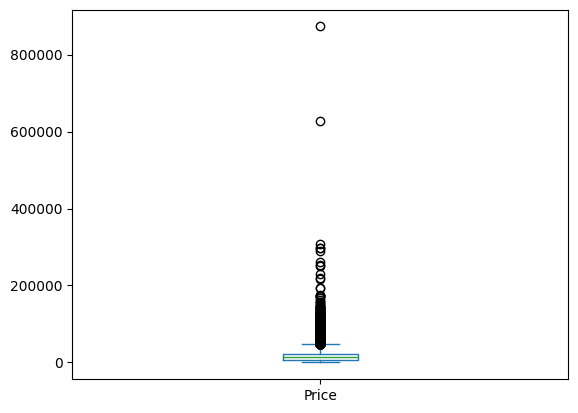

In [183]:
data["Price"].plot(kind="box")

In [184]:
q1=data['Price'].quantile(0.25)
q3=data['Price'].quantile(0.75)
iqr=q3-q1
upper=q3+(1.5*iqr)
lower=q1-(1.5*iqr)
x=data['Price'][(data['Price']>upper) | (data['Price']<lower)]
data["Price"][data["Price"] > 1000000].count()
x=data['Price'][(data['Price']>upper) | (data['Price']<lower)]
x.nlargest(20)

8541     872946
1225     627220
5008     308906
9367     297930
14839    297930
7749     288521
10759    260296
5840     254024
15283    250574
7283     228935
2283     219527
7353     216391
1145     194438
13328    193184
4722     175622
2768     172486
2912     172486
6468     172486
9248     172486
7718     167781
Name: Price, dtype: int64

In [185]:
print(data["Car"][data["Price"] == 872946])

8541    129746.724684
Name: Car, dtype: float64


Trying regression models

In [186]:
from sklearn.model_selection import train_test_split
X=data.drop(columns="Price",axis=1)
y=data["Price"]
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.25,random_state=45,shuffle=True)

In [187]:
from sklearn.linear_model import LinearRegression,SGDRegressor,Lasso,Ridge
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,median_absolute_error 

LinearRegressionModel = LinearRegression(fit_intercept=True,copy_X=True,n_jobs=-1)
SGDRegressionModel = SGDRegressor(alpha=0.1,random_state=33,penalty='l2',loss = 'huber')
LassoRegressionModel = Lasso(alpha=1.0,random_state=33)
RidgeRegressionModel = Ridge(alpha=1.0,random_state=33)
RandomForestRegressorModel = RandomForestRegressor(n_estimators=1000,max_depth=8, random_state=33)
GBRModel = GradientBoostingRegressor(n_estimators=500,max_depth=7,learning_rate = 1.5 ,random_state=33)
SVRModel = SVR(C = 1.0 ,epsilon=0.1,kernel = 'rbf') 
DecisionTreeRegressorModel = DecisionTreeRegressor( max_depth=3,random_state=33)
KNeighborsRegressorModel = KNeighborsRegressor(n_neighbors = 5, weights='uniform',algorithm = 'auto')    

Models = [LinearRegressionModel,SGDRegressionModel,LassoRegressionModel,RidgeRegressionModel,RandomForestRegressorModel,
          GBRModel,SVRModel,DecisionTreeRegressorModel,KNeighborsRegressorModel]



for Model in Models : 
    print(f'for Model {str(Model).split("(")[0]}')
    Model.fit(X_train, y_train)
    print(f'Train Score is : {Model.score(X_train, y_train)}')
    print(f'Test Score is : {Model.score(X_test, y_test)}')
    y_pred = Model.predict(X_test)
    print(f'MAE value is  : {mean_absolute_error(y_test, y_pred)}')
    print(f'MSE value is  : {mean_squared_error(y_test, y_pred)}')
    print(f'MdSE value is  : {median_absolute_error(y_test, y_pred)}')
    print('=================================================')
    




for Model LinearRegression
Train Score is : 0.2575106032552853
Test Score is : 0.26826699874768656
MAE value is  : 10147.977470671252
MSE value is  : 237409570.5847223
MdSE value is  : 7462.44473950984
for Model SGDRegressor
Train Score is : -38.40235603727574
Test Score is : -74.12093786076812
MAE value is  : 67153.94994960165
MSE value is  : 24372864923.304134
MdSE value is  : 46694.13187545318
for Model Lasso
Train Score is : 0.2574819137430495
Test Score is : 0.268428847516921
MAE value is  : 10145.600044985214
MSE value is  : 237357059.0173366
MdSE value is  : 7457.9929098356515
for Model Ridge
Train Score is : 0.25748864040014197
Test Score is : 0.26861492303249124
MAE value is  : 10144.938072709252
MSE value is  : 237296687.12188804
MdSE value is  : 7463.803724977188
for Model RandomForestRegressor
Train Score is : 0.7906972612714394
Test Score is : 0.647080294272916
MAE value is  : 6304.104739862736
MSE value is  : 114504218.94893137
MdSE value is  : 3902.6504536684306
for Mode

Hyperparameter Tuning

In [ ]:
RandomForestRegressorModel=RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=33
)
print(f'for Model {str(RandomForestRegressorModel).split("(")[0]}')
RandomForestRegressorModel.fit(X_train, y_train)
print(f'Train Score is : {RandomForestRegressorModel.score(X_train, y_train)}')
print(f'Test Score is : {RandomForestRegressorModel.score(X_test, y_test)}')
y_pred = RandomForestRegressorModel.predict(X_test)
print(f'MAE value is  : {mean_absolute_error(y_test, y_pred)}')
print(f'MSE value is  : {mean_squared_error(y_test, y_pred)}')
print(f'MdSE value is  : {median_absolute_error(y_test, y_pred)}')
print('=================================================')

for Model RandomForestRegressor
Train Score is : 0.9612412043785573
Test Score is : 0.7548801042644733
MAE value is  : 4138.534809632579
MSE value is  : 79528747.62891436
MdSE value is  : 1916.2562682539665
